In [20]:
import os
import torch
import matplotlib.pyplot as plt

from data_module import InContextDataGenerator
from model_module import VectorICLTransformer


In [21]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device =", device)

save_path = "saved_models/linear_icl_transformer.pt"  # <- change if needed
ckpt = torch.load(save_path, map_location=device)

model = VectorICLTransformer(
    d_in=ckpt["d_in"],
    d_model=ckpt["d_model"],
    n_layers=ckpt["n_layers"],
    n_heads=ckpt["n_heads"],
    max_seq_len=ckpt["max_seq_len"],
).to(device)

model.load_state_dict(ckpt["model_state_dict"])
model.eval()

print("Loaded model from:", save_path)
print({k: ckpt[k] for k in ["d_in","d_model","n_layers","n_heads","max_seq_len","task"] if k in ckpt})


device = cuda
Loaded model from: saved_models/linear_icl_transformer.pt
{'d_in': 20, 'd_model': 256, 'n_layers': 12, 'n_heads': 8, 'max_seq_len': 256, 'task': 'linear'}


In [22]:
@torch.no_grad()
def ols_predict_yquery(tokens, targets, k):
    """
    tokens:  (B, 2k+1, d) = [x1,y1,...,xk,yk,x_query]
    targets: (B, k+1)     = [y1,...,yk,y_query]
    returns: yhat_query_ols: (B,)
    """
    # Extract training data
    X = tokens[:, 0:2*k:2, :]            # (B, k, d)  x1..xk
    y = targets[:, :k].unsqueeze(-1)     # (B, k, 1)  y1..yk
    xq = tokens[:, 2*k, :]               # (B, d)     x_query

    # Solve least squares: minimize ||X w - y||_2  (done per batch element)
    # torch.linalg.lstsq supports batched A and B.
    sol = torch.linalg.lstsq(X, y).solution    # (B, d, 1)

    # Predict y_query = x_query^T w_hat
    yhat = (xq.unsqueeze(1) @ sol).squeeze(-1).squeeze(-1)  # (B,)
    return yhat


In [23]:
@torch.no_grad()
def evaluate_transformer_vs_ols(
    model,
    d=20,
    k_list=(1, 2, 4, 8, 16, 32, 41),
    N=500,
    batch_size=250,          # process N trials in chunks to avoid OOM
    seed=0,
    device="cpu",
):
    gen = InContextDataGenerator(d=d, device=device, seed=seed)

    results = []  # list of dicts

    for k in k_list:
        n_done = 0
        tf_sqerr_sum = 0.0
        ols_sqerr_sum = 0.0

        while n_done < N:
            B = min(batch_size, N - n_done)

            batch = gen.sample_batch(
                task="linear",
                batch_size=B,
                k=k,
                effective_dim=None,    # for standard linear, no masking; set to d for full-d curriculum style
            )

            tokens = batch.tokens.to(device)
            targets = batch.targets.to(device)
            y_true = targets[:, -1]  # (B,)

            # Transformer predicts all y's; we take y_query = last position
            yhat_tf = model(tokens)[:, -1]  # (B,)

            # OLS prediction of y_query from (x1,y1..xk,yk) and x_query
            yhat_ols = ols_predict_yquery(tokens, targets, k)  # (B,)

            tf_sqerr_sum += float(((yhat_tf - y_true) ** 2).sum().cpu())
            ols_sqerr_sum += float(((yhat_ols - y_true) ** 2).sum().cpu())

            n_done += B

        tf_mse = tf_sqerr_sum / N
        ols_mse = ols_sqerr_sum / N

        results.append({"k": k, "transformer_mse": tf_mse, "ols_mse": ols_mse})
        print(f"k={k:>3} | Transformer MSE={tf_mse:.3e} | OLS MSE={ols_mse:.3e}")

    return results


In [24]:
d = ckpt["d_in"]
k_list = list(range(1, 41))   # k = 1, 2, ..., 40
N = 10000

results = evaluate_transformer_vs_ols(
    model=model,
    d=d,
    k_list=k_list,
    N=N,
    batch_size=200,   # smaller batch to be safe on memory
    seed=123,
    device=device,
)


k=  1 | Transformer MSE=1.907e+01 | OLS MSE=1.902e+01
k=  2 | Transformer MSE=1.795e+01 | OLS MSE=1.792e+01
k=  3 | Transformer MSE=1.698e+01 | OLS MSE=1.692e+01
k=  4 | Transformer MSE=1.594e+01 | OLS MSE=1.591e+01
k=  5 | Transformer MSE=1.536e+01 | OLS MSE=1.528e+01
k=  6 | Transformer MSE=1.438e+01 | OLS MSE=1.432e+01
k=  7 | Transformer MSE=1.322e+01 | OLS MSE=1.314e+01
k=  8 | Transformer MSE=1.171e+01 | OLS MSE=1.166e+01
k=  9 | Transformer MSE=1.095e+01 | OLS MSE=1.089e+01
k= 10 | Transformer MSE=1.040e+01 | OLS MSE=1.030e+01
k= 11 | Transformer MSE=9.092e+00 | OLS MSE=9.022e+00
k= 12 | Transformer MSE=8.319e+00 | OLS MSE=8.262e+00
k= 13 | Transformer MSE=7.043e+00 | OLS MSE=6.958e+00
k= 14 | Transformer MSE=6.031e+00 | OLS MSE=5.955e+00
k= 15 | Transformer MSE=5.187e+00 | OLS MSE=5.063e+00
k= 16 | Transformer MSE=4.038e+00 | OLS MSE=3.931e+00
k= 17 | Transformer MSE=2.998e+00 | OLS MSE=2.863e+00
k= 18 | Transformer MSE=2.270e+00 | OLS MSE=2.058e+00
k= 19 | Transformer MSE=1.30

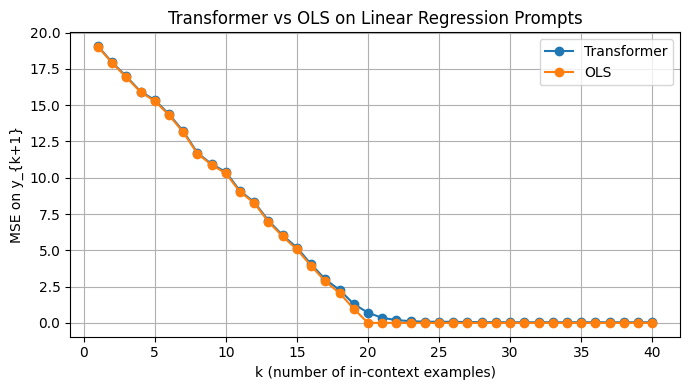

In [25]:
ks = [r["k"] for r in results]
tf = [r["transformer_mse"] for r in results]
ols = [r["ols_mse"] for r in results]

plt.figure(figsize=(7,4))
plt.plot(ks, tf, marker="o", label="Transformer")
plt.plot(ks, ols, marker="o", label="OLS")
plt.xlabel("k (number of in-context examples)")
plt.ylabel("MSE on y_{k+1}")
plt.title("Transformer vs OLS on Linear Regression Prompts")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
